# Swim Metrics

Loads the processed output from `postprocess.ipynb` and extracts 8 biomechanical metrics **one at a time**,
each with an explanation of the method and why it is appropriate.

| Column | Units | Notes |
|---|---|---|
| `time_s` | s | Uniform 50 Hz grid |
| `dist_m` | m | Cumulative net displacement |
| `vel_ms` | m/s | LP-filtered at 2.5 Hz — **primary signal** for stroke-level analysis |
| `accel_ms2` | m/s² | LP-filtered at 0.5 Hz — slow trend only, not per-stroke bursts |

**Physical note:** `vel_ms` swings both positive (pull phase, paddle moving through water) and negative
(recovery phase, paddle returning). Every metric is built around this bidirectional signal.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks
from scipy.stats import variation
from scipy.integrate import trapezoid
from scipy.ndimage import label

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


In [3]:

FS = 50.0          # Hz — uniform grid set in postprocess.ipynb
DT = 1.0 / FS      # seconds per sample

df  = pd.read_csv("processed/swim_20260430_153759.csv.csv")
t   = df["time_s"].values
d   = df["dist_m"].values
vel = df["vel_ms"].values
acc = df["accel_ms2"].values

print(f"Loaded {len(df)} samples  |  {t[-1]:.2f} s  |  {FS} Hz")
df.describe().round(4)

Loaded 2024 samples  |  40.46 s  |  50.0 Hz


,time_s,dist_m,vel_ms,accel_ms2
count,2024.0000,2024.0000,2024.0000,2024.0000
mean,20.2300,0.3772,0.1710,0.0003
std,11.6885,3.5291,0.4426,0.2114
min,0.0000,-4.6266,-0.7995,-0.5997
25%,10.1150,-2.4988,-0.0746,-0.1009
50%,20.2300,-0.1482,0.2872,-0.0111
75%,30.3450,3.2823,0.5655,0.0936
max,40.4600,6.9301,0.8282,0.6102


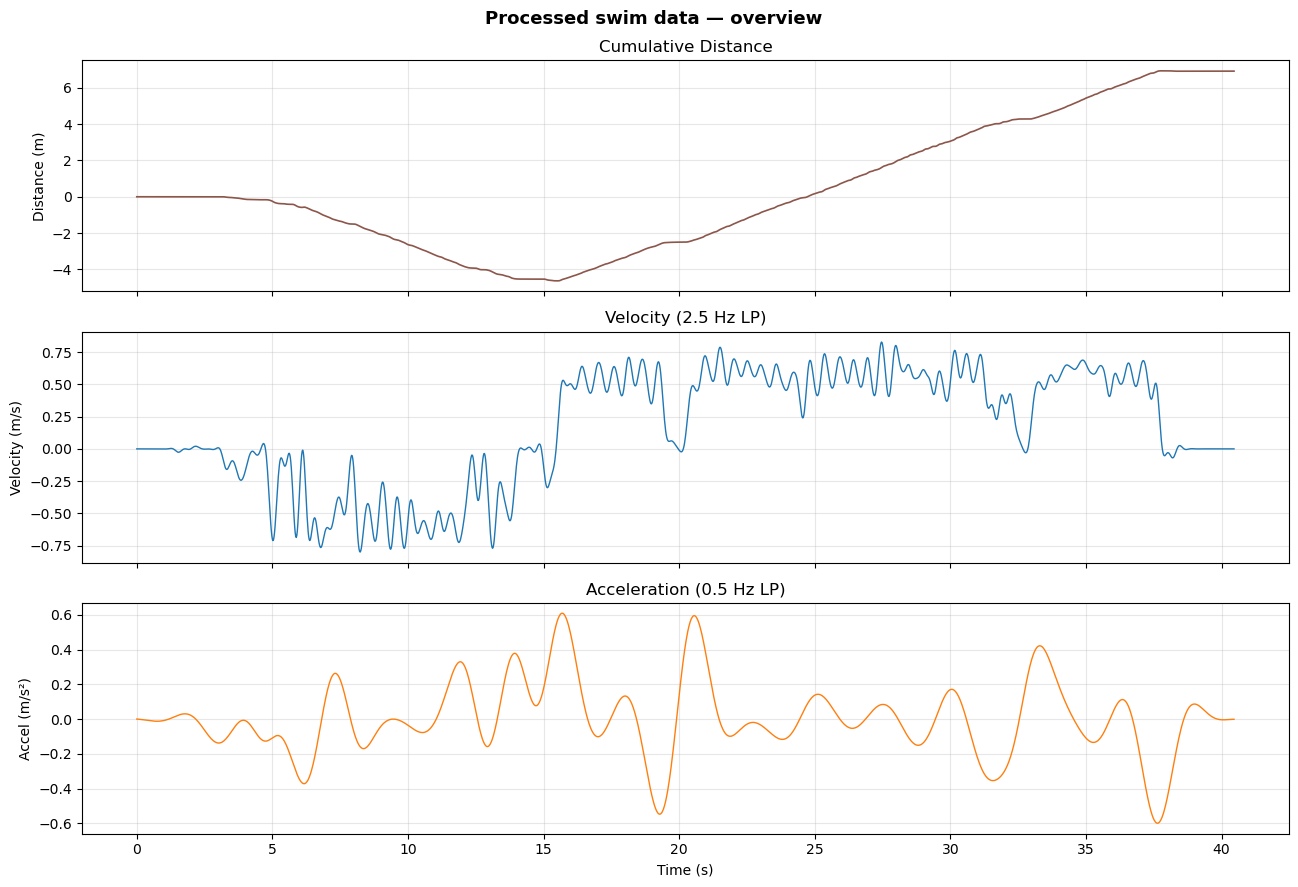

In [4]:
# ── Quick overview of the three time series ──────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(t, d,   color="#8c564b", lw=1.2); axes[0].set_ylabel("Distance (m)");       axes[0].set_title("Cumulative Distance")
axes[1].plot(t, vel, color="#1f77b4", lw=1.0); axes[1].set_ylabel("Velocity (m/s)");     axes[1].set_title("Velocity (2.5 Hz LP)")
axes[2].plot(t, acc, color="#ff7f0e", lw=1.0); axes[2].set_ylabel("Accel (m/s\u00b2)"); axes[2].set_title("Acceleration (0.5 Hz LP)")
axes[2].set_xlabel("Time (s)")
plt.suptitle("Processed swim data — overview", fontsize=13, fontweight="bold")
plt.tight_layout()

---
## Metric 1 — Stroke Rate

**What it is:** The number of stroke cycles per minute — the fundamental tempo of the swim.

**Method: Fast Fourier Transform (FFT)**

The FFT decomposes the velocity signal into its constituent sine waves and tells you how much
energy is at each frequency. Because each stroke cycle produces a repeating velocity pattern
(positive pull → negative recovery), the stroke rate shows up as a clear spike in the frequency
domain.

**Why FFT and not peak counting?**  
FFT gives you the global average frequency across the whole session with no threshold to tune.
It works even when individual strokes vary in amplitude (e.g. fatigue mid-session). Peak counting
(Metric 2) will give the per-stroke picture; FFT gives the aggregate.

**Key steps:**
1. `rfft(vel - mean)` — the `- mean` removes the DC offset (net forward drift) so it doesn't
   dominate the spectrum. `rfft` (real FFT) discards the redundant negative-frequency half.
2. `rfftfreq(N, d=DT)` — maps each FFT bin to its actual frequency in Hz.
3. Search the **physiological band 0.3–3 Hz** (18–180 cycles/min) to ignore noise outside
   the range of human stroke rates.

Dominant frequency  : 0.618 Hz
Stroke rate         : 37.1 cycles/min
Stroke period       : 1.619 s/cycle


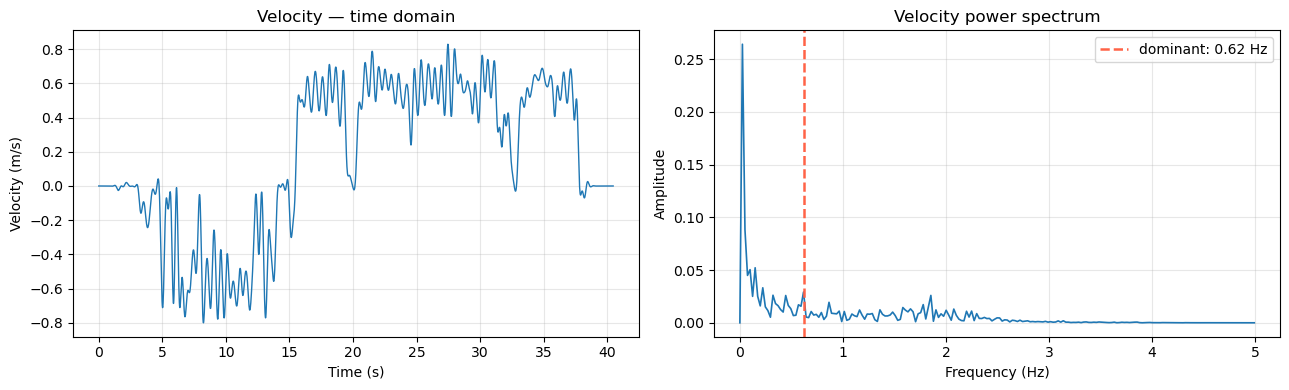

In [5]:
N        = len(vel)
freqs    = rfftfreq(N, d=DT)                    # frequency axis in Hz
spectrum = np.abs(rfft(vel - vel.mean())) / N   # normalised amplitude

# Find the dominant frequency inside the physiological stroke-rate band
band         = (freqs >= 0.3) & (freqs <= 3.0)
stroke_freq  = freqs[band][np.argmax(spectrum[band])]   # Hz
stroke_rate_spm = stroke_freq * 60                      # cycles/min
stroke_period   = 1.0 / stroke_freq                     # s — reused in later metrics

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t, vel, color="#1f77b4", lw=1.0)
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_title("Velocity — time domain")

plot_mask = freqs <= 5
axes[1].plot(freqs[plot_mask], spectrum[plot_mask], color="#1f77b4", lw=1.2)
axes[1].axvline(stroke_freq, color="tomato", ls="--", lw=1.8,
                label=f"dominant: {stroke_freq:.2f} Hz")
axes[1].set_xlabel("Frequency (Hz)"); axes[1].set_ylabel("Amplitude")
axes[1].set_title("Velocity power spectrum"); axes[1].legend()
plt.tight_layout()

print(f"Dominant frequency  : {stroke_freq:.3f} Hz")
print(f"Stroke rate         : {stroke_rate_spm:.1f} cycles/min")
print(f"Stroke period       : {stroke_period:.3f} s/cycle")

---
## Metric 2 — Stroke Count and Per-Stroke Timing

**What it is:** The exact index (time) of every pull peak and every recovery trough, and the
interval between consecutive strokes.

**Method: `scipy.signal.find_peaks`**

`find_peaks` scans the array for local maxima. Applied to `vel` it finds pull peaks; applied
to `-vel` (flipped) it finds recovery troughs as if they were peaks.

**Three guard parameters keep false detections out:**

| Parameter | Value | Meaning |
|---|---|---|
| `height=0` | 0 m/s | Only accept peaks above zero (discard noise dips) |
| `distance` | 40% of stroke period in samples | Two real strokes can't be closer than this |
| `prominence` | 5% of 95th-pct velocity | Peak must stand out above its local baseline |

**Why `distance` uses the stroke period from Metric 1:**  
Setting a hard minimum gap between detections in *samples* (not seconds) is the most reliable
way to prevent the algorithm from double-detecting the same stroke due to small noise bumps
on the peak.

The detected peaks are stored as `pull_peaks` and `recov_peaks` — reused in every following metric.

Pull peaks detected     : 23
Recovery troughs        : 14
Inter-stroke interval   : 1.588 +/- 1.909 s
Stroke rate from peaks  : 37.8 cycles/min  (FFT gave 37.1)


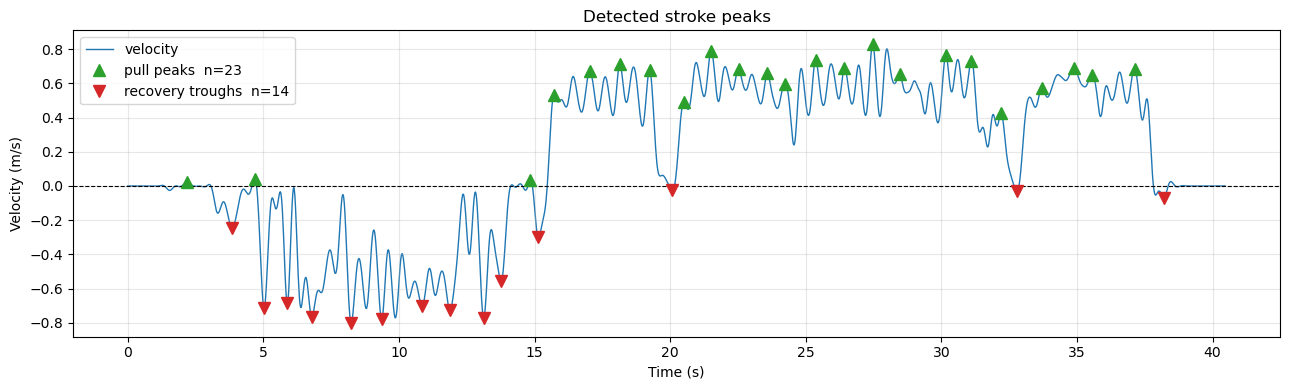

In [6]:
min_dist = int(FS * stroke_period * 0.40)              # 40% of period → samples
min_prom = 0.05 * np.percentile(np.abs(vel), 95)       # 5% of robust peak velocity

pull_peaks,  pull_props  = find_peaks( vel, height=0, distance=min_dist, prominence=min_prom)
recov_peaks, recov_props = find_peaks(-vel, height=0, distance=min_dist, prominence=min_prom)

plt.figure(figsize=(13, 4))
plt.plot(t, vel, color="#1f77b4", lw=1.0, label="velocity", zorder=1)
plt.plot(t[pull_peaks],  vel[pull_peaks],  "^", color="#2ca02c", ms=8,
         label=f"pull peaks  n={len(pull_peaks)}", zorder=3)
plt.plot(t[recov_peaks], vel[recov_peaks], "v", color="#d62728", ms=8,
         label=f"recovery troughs  n={len(recov_peaks)}", zorder=3)
plt.axhline(0, color="black", lw=0.8, ls="--")
plt.xlabel("Time (s)"); plt.ylabel("Velocity (m/s)")
plt.title("Detected stroke peaks")
plt.legend(); plt.tight_layout()

# Pull amplitudes array — reused in Metrics 3, 4, 8
pull_amp  = pull_props["peak_heights"]
recov_amp = recov_props["peak_heights"]

if len(pull_peaks) > 1:
    isi = np.diff(t[pull_peaks])   # inter-stroke intervals
    print(f"Pull peaks detected     : {len(pull_peaks)}")
    print(f"Recovery troughs        : {len(recov_peaks)}")
    print(f"Inter-stroke interval   : {isi.mean():.3f} +/- {isi.std():.3f} s")
    print(f"Stroke rate from peaks  : {60/isi.mean():.1f} cycles/min  (FFT gave {stroke_rate_spm:.1f})")

---
## Metric 3 — Pull / Recovery Asymmetry

**What it is:** How different the peak pull velocity is from the peak recovery velocity.
A symmetric stroke has equal effort in both directions.

**Relationship to bilateral asymmetry:**  
True *bilateral* asymmetry (left arm vs right arm) requires two sensors. With a single 1-D
sensor we can only compare the two phases of each cycle. If the pull is much stronger than
the recovery, it suggests the swimmer is more explosive in one direction — which can be a
proxy for dominant-arm dominance in technique, or a deliberate drill pattern.

**Formula:**
$$AI = \frac{|\bar{A}_{pull} - \bar{A}_{recov}|}{\max(\bar{A}_{pull},\ \bar{A}_{recov})}$$

- `0%` = perfectly balanced phases  
- `>20%` = one phase clearly dominates

**Method:** `find_peaks` from Metric 2 already found both peak sets. Here we just compute
descriptive statistics on their amplitude arrays.

Mean pull amplitude     : 0.5792 m/s
Mean recovery amplitude : 0.5115 m/s
Asymmetry Index (AI)    : 11.7%
Pattern                 : pull-dominant
Interpretation          : moderate (10-20%)


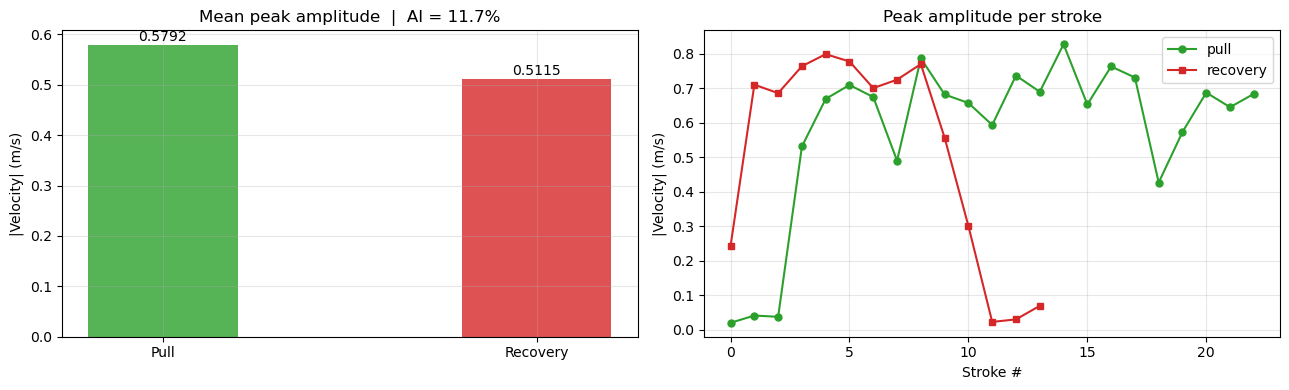

In [7]:
p_mean = pull_amp.mean()
r_mean = recov_amp.mean()
AI     = abs(p_mean - r_mean) / max(p_mean, r_mean)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(["Pull", "Recovery"], [p_mean, r_mean],
            color=["#2ca02c", "#d62728"], alpha=0.8, width=0.4)
axes[0].set_ylabel("|Velocity| (m/s)")
axes[0].set_title(f"Mean peak amplitude  |  AI = {AI*100:.1f}%")
for i, v in enumerate([p_mean, r_mean]):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", va="bottom")

axes[1].plot(range(len(pull_amp)),  pull_amp,  "o-", color="#2ca02c", ms=5, label="pull")
axes[1].plot(range(len(recov_amp)), recov_amp, "s-", color="#d62728", ms=5, label="recovery")
axes[1].set_xlabel("Stroke #"); axes[1].set_ylabel("|Velocity| (m/s)")
axes[1].set_title("Peak amplitude per stroke")
axes[1].legend(); plt.tight_layout()

dominant = "pull-dominant" if p_mean > r_mean else "recovery-dominant"
print(f"Mean pull amplitude     : {p_mean:.4f} m/s")
print(f"Mean recovery amplitude : {r_mean:.4f} m/s")
print(f"Asymmetry Index (AI)    : {AI*100:.1f}%")
print(f"Pattern                 : {dominant}")
print(f"Interpretation          : {'balanced (<10%)' if AI < 0.10 else 'moderate (10-20%)' if AI < 0.20 else 'high (>20%) -- review technique'}")

---
## Metric 4 — Velocity Variability (Coefficient of Variation)

**What it is:** How consistent the pull strength is from stroke to stroke.

**Method: Coefficient of Variation (CV) on stroke peak heights**

$$CV = \frac{\sigma}{\mu}$$

where $\sigma$ and $\mu$ are the standard deviation and mean of the pull peak velocities
across all detected strokes.

**Why CV on peaks, not on the raw signal?**  
The raw `vel_ms` signal oscillates by design (pull/recovery cycle). Computing CV on the full
signal would mostly capture the within-stroke oscillation, not the stroke-to-stroke variation.
Extracting one peak value per stroke first reduces it to a series of comparable numbers — then
CV tells you how much those vary across the session.

**Why CV rather than raw std?**  
CV is dimensionless. A swimmer going 0.5 m/s with std 0.05 has CV=10%; a swimmer going
1.0 m/s with std 0.05 has CV=5%. Same absolute variability, but very different relative
consistency. CV lets you compare across sessions and athletes.

Rule of thumb: `CV < 15%` = consistent stroke.

Pull peak velocities
  mean : 0.5792 m/s
  std  : 0.2296 m/s
  CV   : 39.64%
  Interpretation : variable (CV > 15%)


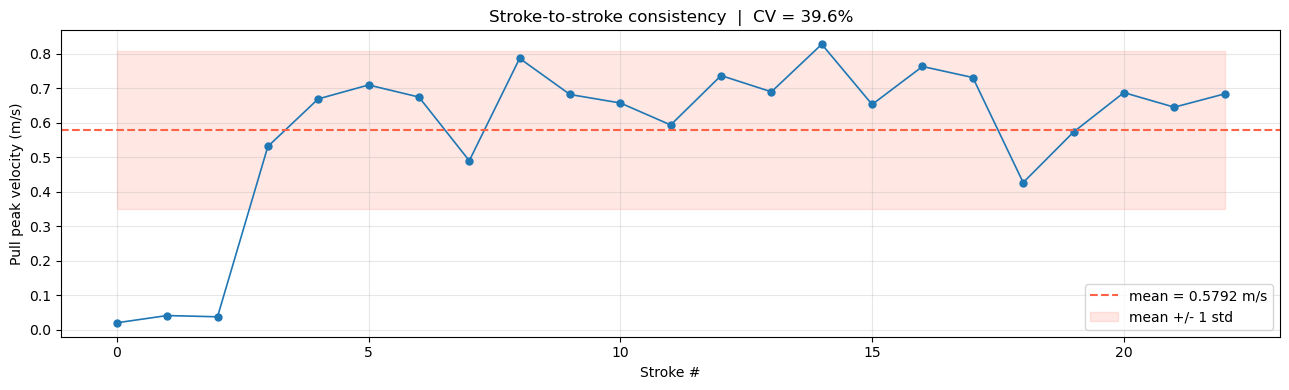

In [8]:
cv = variation(pull_amp)   # scipy.stats: std / mean

plt.figure(figsize=(13, 4))
plt.plot(range(len(pull_amp)), pull_amp, "o-", color="#1f77b4", ms=5, lw=1.2)
plt.axhline(p_mean, color="tomato", ls="--", lw=1.5, label=f"mean = {p_mean:.4f} m/s")
plt.fill_between(
    range(len(pull_amp)),
    p_mean - pull_amp.std(),
    p_mean + pull_amp.std(),
    alpha=0.15, color="tomato", label="mean +/- 1 std"
)
plt.xlabel("Stroke #"); plt.ylabel("Pull peak velocity (m/s)")
plt.title(f"Stroke-to-stroke consistency  |  CV = {cv*100:.1f}%")
plt.legend(); plt.tight_layout()

print(f"Pull peak velocities")
print(f"  mean : {p_mean:.4f} m/s")
print(f"  std  : {pull_amp.std():.4f} m/s")
print(f"  CV   : {cv*100:.2f}%")
print(f"  Interpretation : {'consistent (CV < 15%)' if cv < 0.15 else 'variable (CV > 15%)'}")

---
## Metric 5 — Dead Spots

**What it is:** The windows within each stroke cycle where velocity drops near zero — the
transition between pull and recovery. During a dead spot the swimmer is neither propelling
nor recovering: drag decelerates them with no compensating force.

**Method: Threshold + connected-component labelling (`scipy.ndimage.label`)**

1. **Threshold:** define the dead zone as `|vel_ms| < 10% of peak velocity`. This is a
   relative threshold, so it adapts to the swimmer's speed.
2. **Binary mask:** produce a boolean array — `True` where velocity is in the dead zone.
3. **`label(mask)`:** identifies every contiguous run of `True` values and gives each one
   a unique integer. This is the same connected-component algorithm used in image processing
   to count distinct blobs — applied here to a 1-D signal.

**Why `label` instead of a loop?**  
A hand-written loop iterating sample by sample would work, but `label` handles edge cases
(regions at the start/end of the signal, single-sample regions) without extra code, and
runs in compiled C internally.

Threshold           : +/- 0.0708 m/s (10% of 95th-pct velocity 0.7083)
Dead spot count     : 13
Mean duration       : 693.8 ms
Max duration        : 3180.0 ms
Total dead time     : 9.02 s  (22.3% of session)


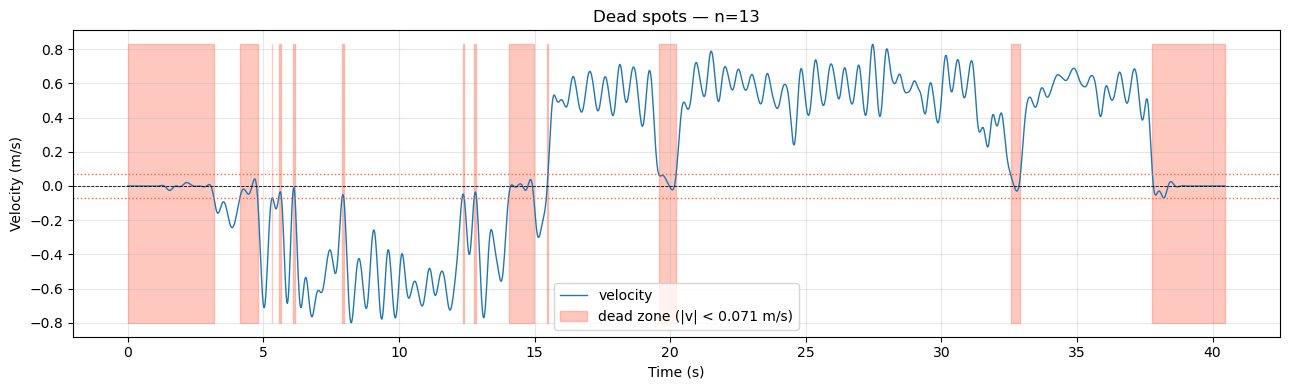

In [9]:
peak_vel   = np.percentile(np.abs(vel), 95)   # robust peak (ignores occasional spikes)
threshold  = 0.10 * peak_vel
dead_mask  = np.abs(vel) < threshold

labeled_arr, n_spots = label(dead_mask)
durations_s = [(labeled_arr == i).sum() / FS for i in range(1, n_spots + 1)]

plt.figure(figsize=(13, 4))
plt.plot(t, vel, color="#1f77b4", lw=1.0, label="velocity", zorder=2)
plt.fill_between(t, vel.min(), vel.max(), where=dead_mask,
                 color="tomato", alpha=0.35, label=f"dead zone (|v| < {threshold:.3f} m/s)", zorder=1)
plt.axhline( threshold, color="tomato", ls=":", lw=1.0)
plt.axhline(-threshold, color="tomato", ls=":", lw=1.0)
plt.axhline(0, color="black", lw=0.6, ls="--")
plt.xlabel("Time (s)"); plt.ylabel("Velocity (m/s)")
plt.title(f"Dead spots — n={n_spots}")
plt.legend(); plt.tight_layout()

print(f"Threshold           : +/- {threshold:.4f} m/s (10% of 95th-pct velocity {peak_vel:.4f})")
print(f"Dead spot count     : {n_spots}")
if durations_s:
    print(f"Mean duration       : {np.mean(durations_s)*1000:.1f} ms")
    print(f"Max duration        : {np.max(durations_s)*1000:.1f} ms")
    print(f"Total dead time     : {sum(durations_s):.2f} s  ({sum(durations_s)/t[-1]*100:.1f}% of session)")

---
## Metric 6 — Propulsive Impulse per Stroke

**What it is:** The area under the positive part of the velocity curve for each stroke cycle —
the distance the swimmer *gains* from one pull.

**Physics:** impulse = $\int v\, dt$. For a constant force this equals $\Delta x$ (displacement).
Summing only the positive half isolates the propulsive contribution and ignores the recovery
phase where the paddle returns through water.

**Method: zero-crossing segmentation + `scipy.integrate.trapezoid`**

1. **Zero crossings:** find every index where `vel_ms` changes sign. Each crossing boundary
   separates a pull segment from a recovery segment.
2. **Classify:** if a segment's mean is positive → pull phase → integrate it.
3. **`trapezoid(seg, dx=DT)`:** the trapezoidal rule approximates the integral by summing
   trapezoids between consecutive samples. More accurate than the Euler (rectangle) sum
   because it uses both endpoints of each interval rather than just one.

**Units:** m/s × s = m — distance gained per pull.

Pull strokes analysed   : 14
Mean impulse / stroke   : 0.8278 m  (distance gained per pull)
Std  impulse / stroke   : 1.8514 m  (CV = 223.6%)
Total propulsive dist   : 11.589 m


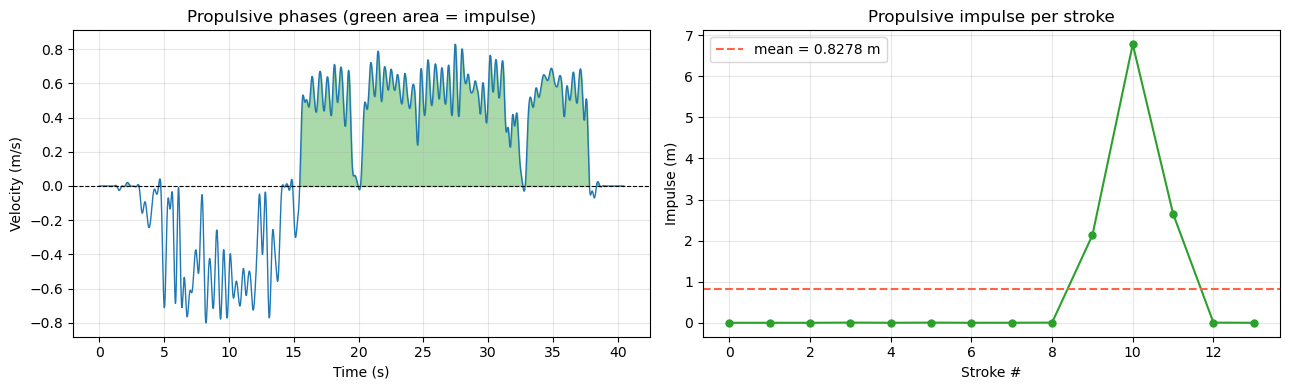

In [10]:
# Zero-crossing indices: where the sign of velocity changes
signs_filled  = pd.Series(np.sign(vel)).replace(0, np.nan).ffill().bfill().values
crossings     = np.where(np.diff(signs_filled))[0] + 1   # first sample of each new phase

pull_impulses = []
pull_windows  = []   # (start, end) index pairs — used for shading the plot

for i in range(len(crossings) - 1):
    a, b = crossings[i], crossings[i + 1]
    seg  = vel[a:b]
    if len(seg) > 1 and seg.mean() > 0:          # pull phase
        imp = trapezoid(np.maximum(seg, 0), dx=DT)
        pull_impulses.append(imp)
        pull_windows.append((a, b))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t, vel, color="#1f77b4", lw=1.0, zorder=2)
for a, b in pull_windows:
    axes[0].fill_between(t[a:b], 0, vel[a:b], alpha=0.40, color="#2ca02c", zorder=1)
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_title("Propulsive phases (green area = impulse)")

imp_arr = np.array(pull_impulses)
axes[1].plot(range(len(imp_arr)), imp_arr, "o-", color="#2ca02c", ms=5)
axes[1].axhline(imp_arr.mean(), color="tomato", ls="--", lw=1.5, label=f"mean = {imp_arr.mean():.4f} m")
axes[1].set_xlabel("Stroke #"); axes[1].set_ylabel("Impulse (m)")
axes[1].set_title("Propulsive impulse per stroke")
axes[1].legend(); plt.tight_layout()

print(f"Pull strokes analysed   : {len(imp_arr)}")
print(f"Mean impulse / stroke   : {imp_arr.mean():.4f} m  (distance gained per pull)")
print(f"Std  impulse / stroke   : {imp_arr.std():.4f} m  (CV = {imp_arr.std()/imp_arr.mean()*100:.1f}%)")
print(f"Total propulsive dist   : {imp_arr.sum():.3f} m")

---
## Metric 7 — Stroke Smoothness (Jerk)

**What it is:** Jerk is the rate of change of acceleration — how abruptly the swimmer's
force changes. A smooth, efficient stroke has low jerk; a sharp, jerky technique wastes
energy on unnecessary accelerations and decelerations.

**Kinematic chain:**
$$\text{position} \xrightarrow{\frac{d}{dt}} \text{velocity} \xrightarrow{\frac{d}{dt}} \text{acceleration} \xrightarrow{\frac{d}{dt}} \text{jerk}$$

**Why recompute acceleration from `vel_ms`, not use `accel_ms2`?**  
The `accel_ms2` column in the CSV was derived from a **0.5 Hz** low-pass filter. That cutoff
is below the stroke frequency, so almost all stroke-level detail is already removed. Differentiating
that column would give near-zero jerk — not because the stroke is smooth, but because the signal
was over-filtered. `vel_ms` uses a 2.5 Hz cutoff which preserves stroke shape. We differentiate
it twice here to get meaningful jerk.

**Method: `np.gradient` (twice)**  
`np.gradient` uses central differences for interior points:
$f'[i] = \frac{f[i+1] - f[i-1]}{2\,\Delta t}$  
More accurate than a one-sided difference because it uses the slope across the full interval.
The second argument `DT` tells it the sample spacing so the result comes out in m/s³.

**Summary statistic: RMS Jerk** — square first (makes all values positive), average, then
square root. Plain averaging would cancel positive and negative jerk.

RMS jerk            : 12.841 m/s^3
Mean |velocity|     : 0.4017 m/s
Smoothness index    : 31.967  (lower = smoother; compare across sessions)


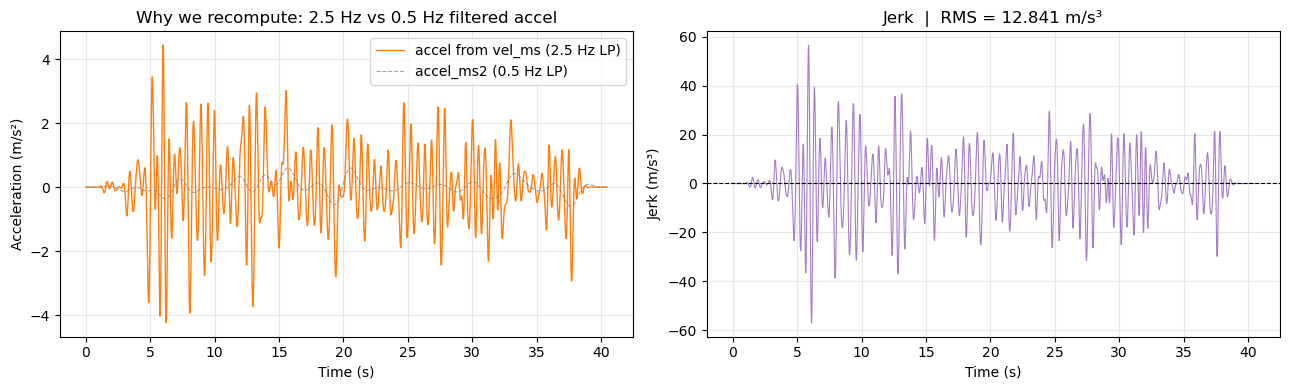

In [11]:
# Recompute acceleration from vel_ms (2.5 Hz LP) — not the 0.5 Hz LP accel_ms2 column
accel_from_vel = np.gradient(vel, DT)        # m/s^2
jerk           = np.gradient(accel_from_vel, DT)  # m/s^3

rms_jerk       = np.sqrt(np.mean(jerk ** 2))
mean_speed     = np.mean(np.abs(vel))
smoothness_idx = rms_jerk / mean_speed        # dimensionless — allows cross-session comparison

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t, accel_from_vel, color="#ff7f0e", lw=1.0, label="accel from vel_ms (2.5 Hz LP)")
axes[0].plot(t, acc,            color="gray",    lw=0.8, ls="--", alpha=0.7, label="accel_ms2 (0.5 Hz LP)")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Acceleration (m/s\u00b2)")
axes[0].set_title("Why we recompute: 2.5 Hz vs 0.5 Hz filtered accel")
axes[0].legend()

axes[1].plot(t, jerk, color="#9467bd", lw=0.8, alpha=0.85)
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Jerk (m/s\u00b3)")
axes[1].set_title(f"Jerk  |  RMS = {rms_jerk:.3f} m/s\u00b3")
plt.tight_layout()

print(f"RMS jerk            : {rms_jerk:.3f} m/s^3")
print(f"Mean |velocity|     : {mean_speed:.4f} m/s")
print(f"Smoothness index    : {smoothness_idx:.3f}  (lower = smoother; compare across sessions)")

---
## Metric 8 — Fatigue Index

**What it is:** Whether pull strength declines over the session — a direct signal of
neuromuscular fatigue.

**Method: Temporal windowing on per-stroke peak velocities**

Divide the stroke sequence into 4 equal quarters. Compute the mean pull peak velocity in
each quarter. A declining trend from Q1 to Q4 indicates fatigue.

$$\text{Fatigue Index} = \frac{\bar{v}_{Q1} - \bar{v}_{Q4}}{\bar{v}_{Q1}} \times 100\%$$

**Why quarters and not a regression slope?**  
Quarters are interpretable without statistics knowledge — a coach can immediately read
"Q1 vs Q4" off a bar chart. A regression slope is more robust for longer sessions; for a
short 40 s recording, quarters give the same information with less complexity.

**What the index means:**
- Positive → peak velocity dropped → fatigue or pacing
- Negative → peak velocity increased → warm-up effect or pacing strategy
- Near 0 → maintained power across the session

Strokes per quarter : ~5
Quarter means (m/s) : [0.2602, 0.6691, 0.7016, 0.646]
Fatigue Index       : -148.2%
                      (negative = warm-up / improving)


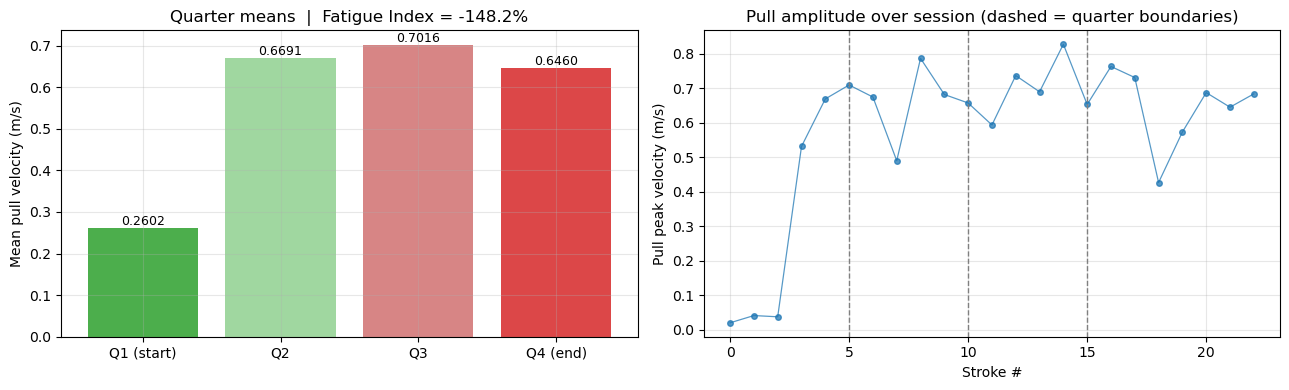

In [12]:
n_strokes = len(pull_amp)
q         = max(1, n_strokes // 4)   # strokes per quarter

window_labels = ["Q1 (start)", "Q2", "Q3", "Q4 (end)"]
window_means  = []
for i in range(4):
    seg = pull_amp[i * q : (i + 1) * q if i < 3 else n_strokes]
    window_means.append(float(seg.mean()) if len(seg) > 0 else float("nan"))

wm = [v for v in window_means if not np.isnan(v)]
fatigue_idx = (wm[0] - wm[-1]) / wm[0] * 100 if len(wm) >= 2 else 0.0

bar_colors = ["#2ca02c", "#90d090", "#d07070", "#d62728"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(window_labels[:len(wm)], wm, color=bar_colors[:len(wm)], alpha=0.85)
axes[0].set_ylabel("Mean pull velocity (m/s)")
axes[0].set_title(f"Quarter means  |  Fatigue Index = {fatigue_idx:.1f}%")
for i, v in enumerate(wm):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

axes[1].plot(range(n_strokes), pull_amp, "o-", color="#1f77b4", ms=4, lw=0.9, alpha=0.75)
for i in range(1, 4):
    axes[1].axvline(i * q, color="gray", ls="--", lw=1.0)
axes[1].set_xlabel("Stroke #"); axes[1].set_ylabel("Pull peak velocity (m/s)")
axes[1].set_title("Pull amplitude over session (dashed = quarter boundaries)")
plt.tight_layout()

print(f"Strokes per quarter : ~{q}")
print(f"Quarter means (m/s) : {[round(v, 4) for v in wm]}")
print(f"Fatigue Index       : {fatigue_idx:.1f}%")
direction = "positive = declining strength" if fatigue_idx > 0 else "negative = warm-up / improving"
print(f"                      ({direction})")

---
## Summary

In [13]:
summary = {
    "1  Stroke Rate":            f"{stroke_rate_spm:.1f} cycles/min  ({stroke_freq:.3f} Hz)",
    "2  Stroke Count (pull)":    f"{len(pull_peaks)}",
    "3  Asymmetry Index":        f"{AI*100:.1f}%  ({dominant})",
    "4  Velocity CV":            f"{cv*100:.1f}%",
    "5  Dead Spots":             f"{n_spots}  (mean {np.mean(durations_s)*1000:.0f} ms, {sum(durations_s)/t[-1]*100:.1f}% of session)",
    "6  Mean Impulse/Stroke":    f"{imp_arr.mean():.4f} m",
    "7  Smoothness Index":       f"{smoothness_idx:.3f}  (RMS jerk {rms_jerk:.3f} m/s^3)",
    "8  Fatigue Index":          f"{fatigue_idx:.1f}%",
}

print("=" * 62)
print(f"{'SWIM METRICS SUMMARY':^62}")
print("=" * 62)
for k, v in summary.items():
    print(f"  {k:<30}  {v}")
print("=" * 62)

                     SWIM METRICS SUMMARY                     
  1  Stroke Rate                  37.1 cycles/min  (0.618 Hz)
  2  Stroke Count (pull)          23
  3  Asymmetry Index              11.7%  (pull-dominant)
  4  Velocity CV                  39.6%
  5  Dead Spots                   13  (mean 694 ms, 22.3% of session)
  6  Mean Impulse/Stroke          0.8278 m
  7  Smoothness Index             31.967  (RMS jerk 12.841 m/s^3)
  8  Fatigue Index                -148.2%
